Name:Prabin Shah
Student id :2419107

In [ ]:
!pip install pillow

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
image_colored= Image.open("/content/drive/MyDrive/AI and Machine Learning/image1.png")

2.1 Exercise - 1:
Complete all the Task.
1. Read and display the image.
• Read the image using the Pillow library and display it.
• You can also use matplotlib to display the image

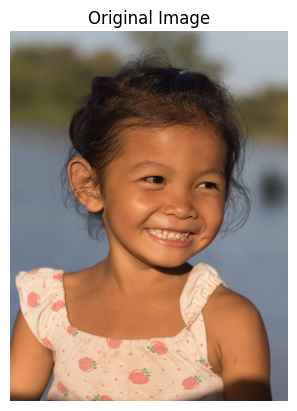

In [ ]:
img_array = np.array(image_colored)

# Display image
plt.imshow(img_array)
plt.title("Original Image")
plt.axis("off")
plt.show()

2. Display Top Left 100×100 Pixels

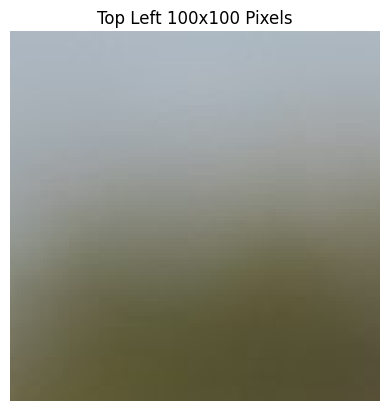

In [ ]:
top_left = img_array[0:100, 0:100]


plt.imshow(top_left)
plt.title("Top Left 100x100 Pixels")
plt.axis("off")
plt.show()

3. Show RGB Color Channels

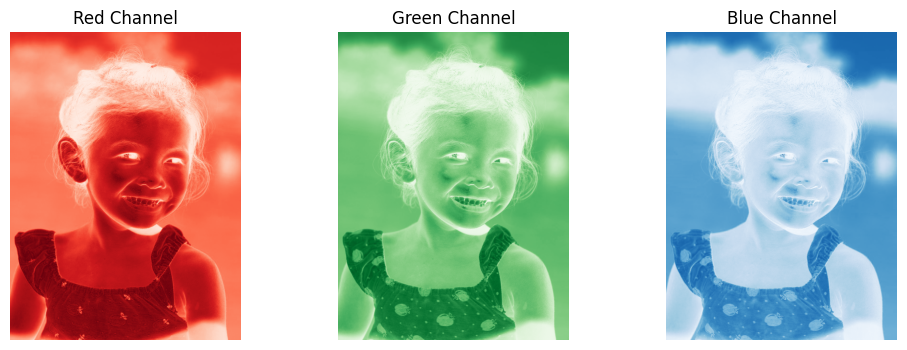

In [ ]:
# Separate channels
R = img_array[:, :, 0]
G = img_array[:, :, 1]
B = img_array[:, :, 2]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap='Reds')
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap='Greens')
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap='Blues')
plt.title("Blue Channel")
plt.axis("off")

plt.show()

4. Modify Top 100×100 Pixels to Value 210

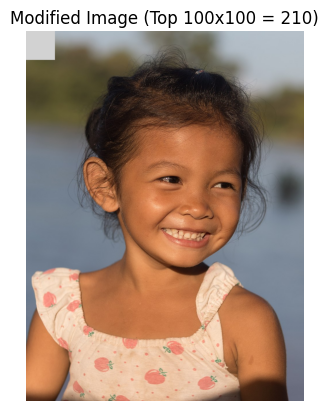

In [ ]:
modified_img = img_array.copy()

modified_img[0:100, 0:100] = 210

plt.imshow(modified_img)
plt.title("Modified Image (Top 100x100 = 210)")
plt.axis("off")
plt.show()

Exercise 2 Solution

1. Load and Display a Grayscale Image

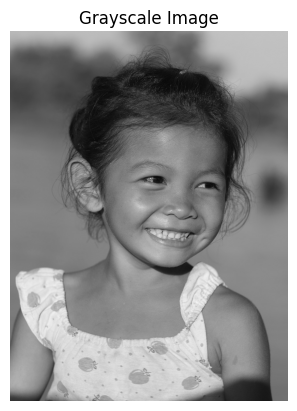

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

gray_image = Image.open("/content/drive/MyDrive/AI and Machine Learning/image1.png").convert("L")

gray_array = np.array(gray_image)

plt.imshow(gray_array, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

2. Extract Middle Section (150 Pixels)

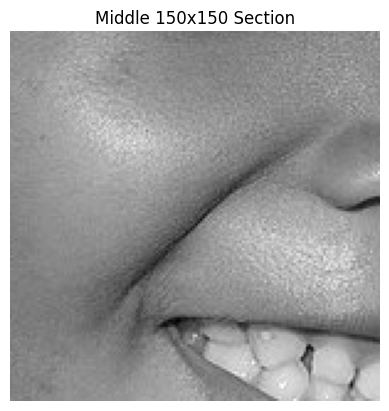

In [ ]:
h, w = gray_array.shape

center_h = h // 2
center_w = w // 2

middle_section = gray_array[center_h-75:center_h+75, center_w-75:center_w+75]

plt.imshow(middle_section, cmap='gray')
plt.title("Middle 150x150 Section")
plt.axis("off")
plt.show()

3. Apply Threshold (Binary Image)

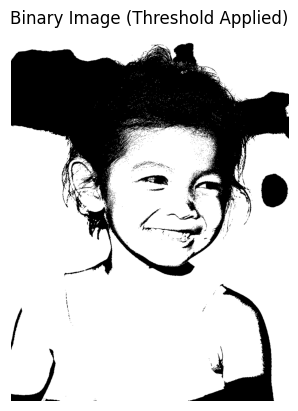

In [ ]:
binary_image = np.where(gray_array < 100, 0, 255)

plt.imshow(binary_image, cmap='gray')
plt.title("Binary Image (Threshold Applied)")
plt.axis("off")
plt.show()

4. Rotate Image 90° Clockwise

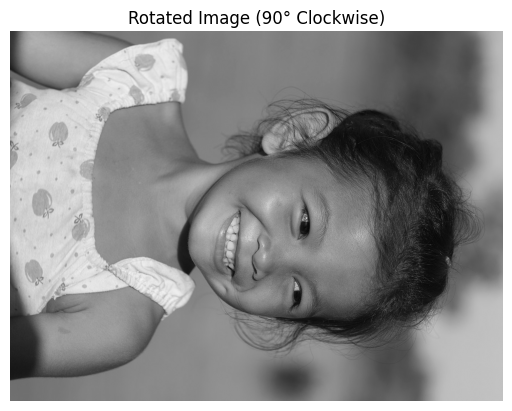

In [ ]:
rotated_image = np.rot90(gray_array, k=-1)

plt.imshow(rotated_image, cmap='gray')
plt.title("Rotated Image (90° Clockwise)")
plt.axis("off")
plt.show()

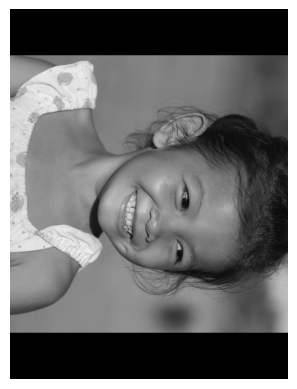

In [ ]:
rotated_image = gray_image.rotate(-90)
plt.imshow(rotated_image, cmap='gray')
plt.axis("off")
plt.show()

5. Convert Grayscale Image to RGB

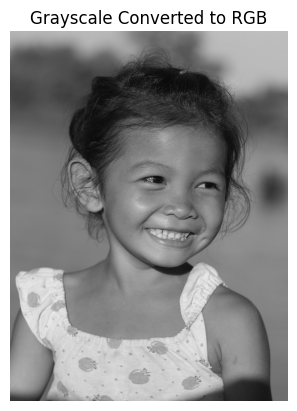

In [ ]:
# Replicate grayscale values across 3 channels
rgb_image = np.stack((gray_array,)*3, axis=-1)

# Display RGB image
plt.imshow(rgb_image)
plt.title("Grayscale Converted to RGB")
plt.axis("off")
plt.show()

Image Compression and Decompression using PCA.

1. Load and Prepare Data

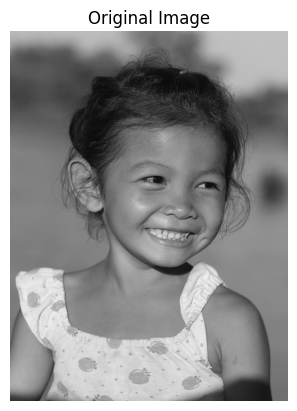

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

image = Image.open("/content/drive/MyDrive/AI and Machine Learning/image1.png").convert("L")

img = np.array(image)

plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")
plt.show()

Standardize (Center the Data)

In [ ]:
img = img.astype(float)

mean = np.mean(img, axis=0)
X = img - mean

Compute Covariance Matrix

In [ ]:
cov_matrix = np.cov(X, rowvar=False)
print("Covariance Matrix Shape:", cov_matrix.shape)

Covariance Matrix Shape: (960, 960)


2. Eigen Decomposition and Principal Components

Compute Eigenvalues and Eigenvectors

In [ ]:
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

Sort Eigenvalues (Descending Order)

In [ ]:
sorted_index = np.argsort(eigen_values)[::-1]

eigen_values = eigen_values[sorted_index]
eigen_vectors = eigen_vectors[:, sorted_index]

Cumulative Explained Variance Plot

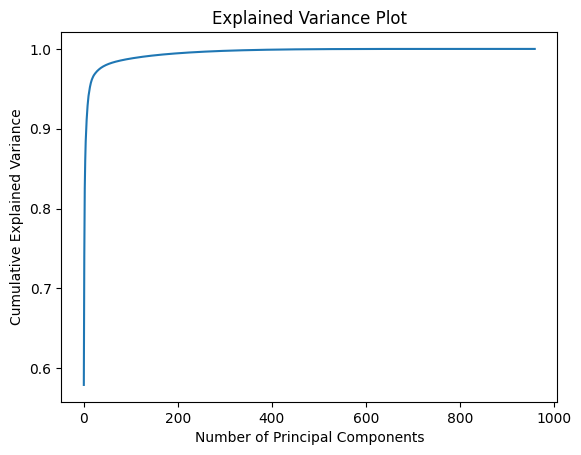

In [ ]:
explained_variance = eigen_values / np.sum(eigen_values)
cumulative_variance = np.cumsum(explained_variance)

plt.plot(cumulative_variance)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance Plot")
plt.show()

3. Reconstruction and Experiments

PCA Compression Function

In [ ]:
def pca_compress(X, eigen_vectors, k):

    pcs = eigen_vectors[:, :k]

    compressed = np.dot(X, pcs)


    reconstructed = np.dot(compressed, pcs.T) + mean

    return reconstructed

Experiment with Different Principal Components

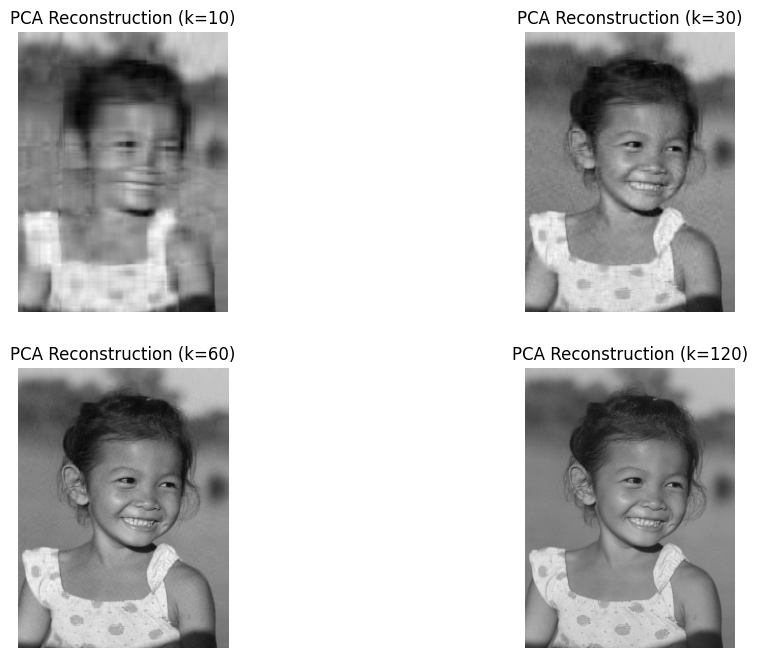

In [ ]:
components = [10, 30, 60, 120]

plt.figure(figsize=(12,8))

for i,k in enumerate(components):

    reconstructed = pca_compress(X, eigen_vectors, k)

    plt.subplot(2,2,i+1)
    plt.imshow(reconstructed, cmap='gray')
    plt.title(f"PCA Reconstruction (k={k})")
    plt.axis("off")

plt.show()